### This jupyter notebook contains contents of the lesson Tree Based models

**Author : Umidjon Sattorov. Machine Learning engineer**

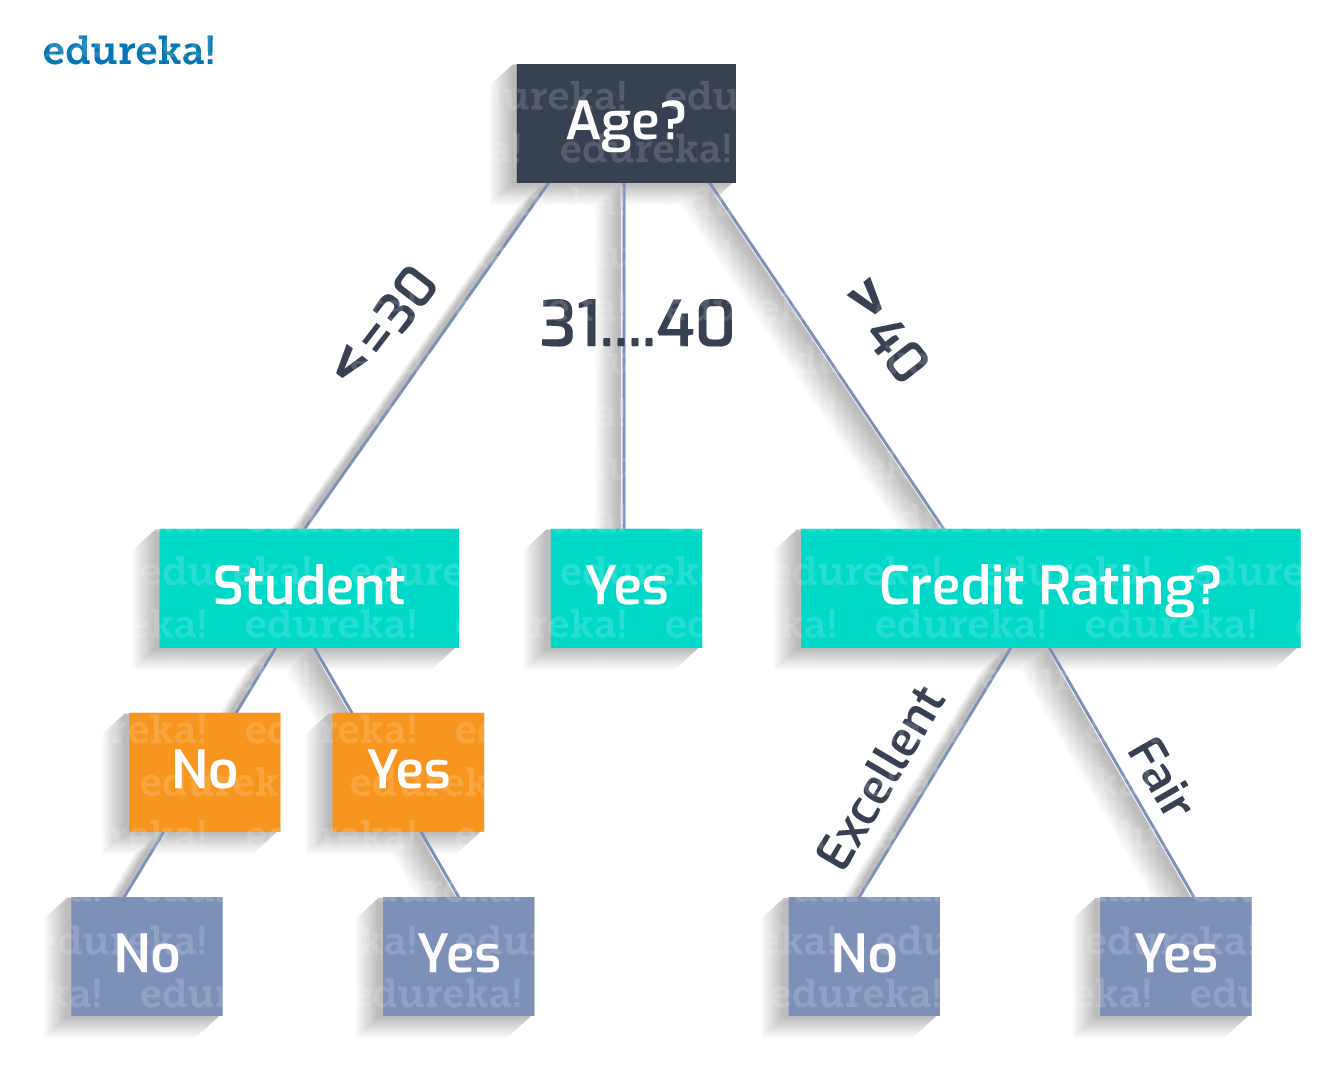

___

## Math Behind Decision trees 

Let's say we have following dataset and we have to make model which can predict whether customer purchases particular product or not based on their age and income.

| Age | Income | Buys |
| --- | ------ | ---- |
| 25  | Low    | No   |
| 28  | High   | No   |
| 35  | Low    | Yes  |
| 40  | Low    | Yes  |
| 42  | High   | Yes  |
| 38  | High   | Yes  |


In [1]:
1-(1/3) ** 2 - (2/3) ** 2

0.4444444444444444

In [2]:
lOW - > 2 YES, 1 NO 
HIGH - > 2 YES, 1 NO

SyntaxError: invalid syntax (621707036.py, line 1)

In [3]:
1 - (1/3) ** 2 - (2/3) ** 2

0.4444444444444444

In [4]:
3 / 6 * 0.444 + 3/6 * 0.444

0.444

For this dataset and task, it is a lot better for us to use decision trees(classifier). Decision tree have many branches which consist of conditional elements with threshold. For constructing this decision tree model, our model firstly find most efficient feature with lowest gini impurity.

2) Then selects this feature as root condition and find thresholds and construct decision tree with this conditional elements.

**First step**

Firstly model finds feature with lowest gini impurity.

**Gini impurity** measures how often you would misclassify a randomly chosen element in a set if you assigned labels randomly based on the label distribution in that set.

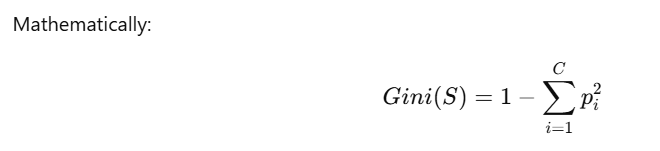

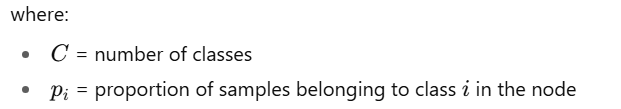

                                        _______________________________

* Calculating parent gini impurity :

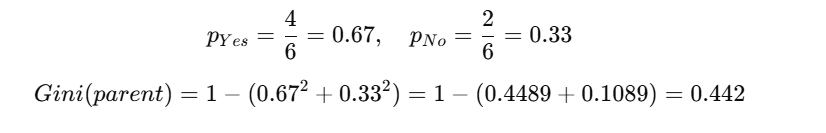

* Secondly, we have to find gini impurity for X features. But for numerical features, I have to find threshold value which can separate values into classes with lowest gini impurity. For that, we can find mean values for every two values(But before, we have to sort value in ascending order.). In our case, age column should be sorted like this.

In [5]:
# Making dataframe and sorting age column
import pandas as pd
import numpy as np

data = {
    "Age": [25, 28, 35, 40, 42, 38],
    "Income": ["Low", "High", "Low", "Low", "High", "High"],
    "Buys": ["No", "No", "Yes", "Yes", "Yes", "Yes"]
}

df = pd.DataFrame(data)
df

,Age,Income,Buys
0,25,Low,No
1,28,High,No
2,35,Low,Yes
3,40,Low,Yes
4,42,High,Yes
5,38,High,Yes


In [6]:
twice_means = [(a + b) / 2 for a, b in zip(df['Age'].iloc[ : 5].values, df['Age'].iloc[1 : ].values)]
twice_means

[np.float64(26.5),
 np.float64(31.5),
 np.float64(37.5),
 np.float64(41.0),
 np.float64(40.0)]

* After this process, we can find divide dataset with threshold and find gini impurity with target variable.

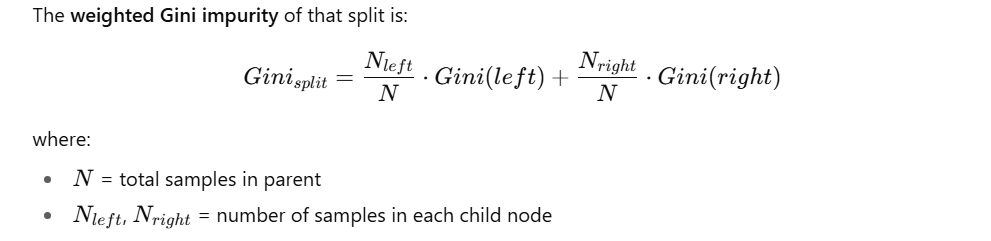

In [7]:
# Binary gini calculator
def bin_gini(num_val_1, num_val_2, all_val) : 
    gini_val = 1 - (num_val_1 / all_val) ** 2 - (num_val_2 / all_val) ** 2
    return gini_val

# Gini calculator with split
def split_gini(gini_left, gini_right, left, right, all_val) :
    gini_split = left * gini_left / all_val + right * gini_right / all_val
    return gini_split

In [8]:
df.sort_values(by = 'Age')

,Age,Income,Buys
0,25,Low,No
1,28,High,No
2,35,Low,Yes
5,38,High,Yes
3,40,Low,Yes
4,42,High,Yes


In [9]:
# Calculating sample division gini using available functions
gini_left = bin_gini(1, 0, 1)
gini_right = bin_gini(1, 4, 5)
result = split_gini(gini_left, gini_right, 1, 5, 6)
result

0.26666666666666655

In [10]:
df['Buys'].value_counts().loc['No']

np.int64(2)

In [11]:
# Function for splitting data and calculating gini values automatic
def split_calculate_gini(df, column_name, thresholds):
    left_data = df[df[column_name] < thresholds]
    right_data = df[df[column_name] >= thresholds]
    gini_left = bin_gini(left_data['Buys'].value_counts().loc['No'], len(left_data) - left_data['Buys'].value_counts().loc['No'], len(left_data))
    gini_right = bin_gini(len(right_data) - right_data['Buys'].value_counts().loc['Yes'], right_data['Buys'].value_counts().loc['Yes'], len(right_data))
    result = split_gini(gini_left, gini_right, len(left_data), len(right_data), len(df))
    return result

gini_vals = [split_calculate_gini(df, 'Age', i) for i in twice_means]
gini_vals

[np.float64(0.26666666666666655),
 np.float64(0.0),
 np.float64(0.22222222222222224),
 np.float64(0.39999999999999997),
 np.float64(0.3333333333333333)]

From the calculated gini values, it is great to select second feature from given twice_means.

In [12]:
twice_means[1]

np.float64(31.5)

* Next this we are gonna do is calculating gini impurity for the second feature(Which is kinda categorical feature -> Ordinal feature). For this, we are going to calculate gini value for each category and calculate overall gini impurity using splitted gini formula.

        Low -> 1(No), 2(Yes)
        High -> 1(No), 2(Yes)

In [13]:
#Gini values for each category
low_gini = bin_gini(1, 2, 3)
high_gini = bin_gini(1, 2, 3)
full_gini = 3/6 * low_gini + 3/6 * high_gini
full_gini

0.4444444444444444

**Lets just build Decision tree model using sklearn and see the structure of the tree**

In [14]:
df['Buys'].apply(lambda x : 1 if x == "Yes" else 0)

0    0
1    0
2    1
3    1
4    1
5    1
Name: Buys, dtype: int64

In [15]:
# Checking how decision tree model can perform in our dataset
from sklearn.tree import DecisionTreeClassifier

# Feature engineering
df['Income'] = df['Income'].apply(lambda x : 1 if x == "High" else 0)
df['Buys'] = df['Buys'].apply(lambda x : 1 if x == "Yes" else 0)

X = df.drop(columns = 'Buys')
y = df['Buys']

dc = DecisionTreeClassifier()
dc.fit(X = X, y = y)
dc

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
# Checking models performance with roc_auc score
dc.predict(X = X)
y

0    0
1    0
2    1
3    1
4    1
5    1
Name: Buys, dtype: int64

* Drawing decision tree model for checking structure

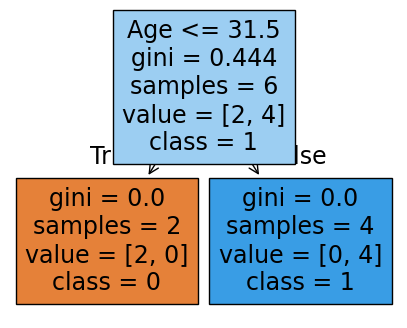

In [17]:
# Visualizing Decision tree model
import matplotlib.pyplot as plt
from sklearn import tree

cols = df.drop(columns = 'Buys').columns
classes = df['Buys'].unique().astype(str)

plt.figure(figsize = (5, 4))
tree.plot_tree(dc, feature_names = cols, class_names = classes, filled = True)
plt.show()

___

**Next hyperparameter we can use instead of Gini impurity is Entropy. This is your time to explore this parameter.**

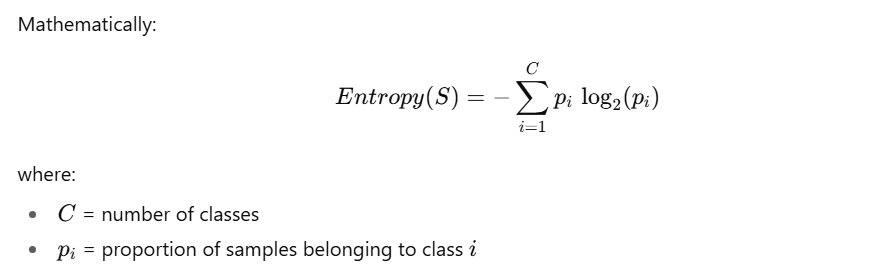

**Actually there are three types of Decision trees : ID3, C4.5(Often use Entropy as impurity metric), CART(Which uses GINI as impurity metric). Other difference between these algorithms are CART creates only binary splits at every node, whereas ID3 can create more than binary splits, such as three splits from one root node.**

____

**Logistic regression**

In [18]:
# Importing necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 6.5)

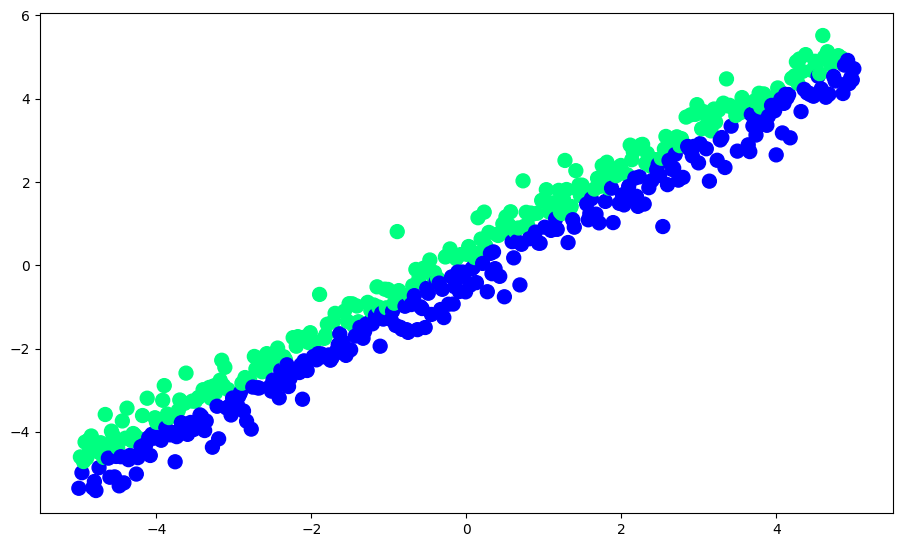

In [19]:
# Generating synthetic data
np.random.seed(13)
n = 500
X = np.zeros(shape = (n, 2))
X[:, 0] = np.linspace(-5, 5, 500)
X[:, 1] = X[:, 0] + 0.5 * np.random.normal(size=n)
y = (X[:, 1] > X[:, 0]).astype(int)
plt.scatter(X[:, 0], X[:, 1], s = 100, c = y, cmap = "winter")
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13)

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_score(y_pred_lr, y_test)

0.992

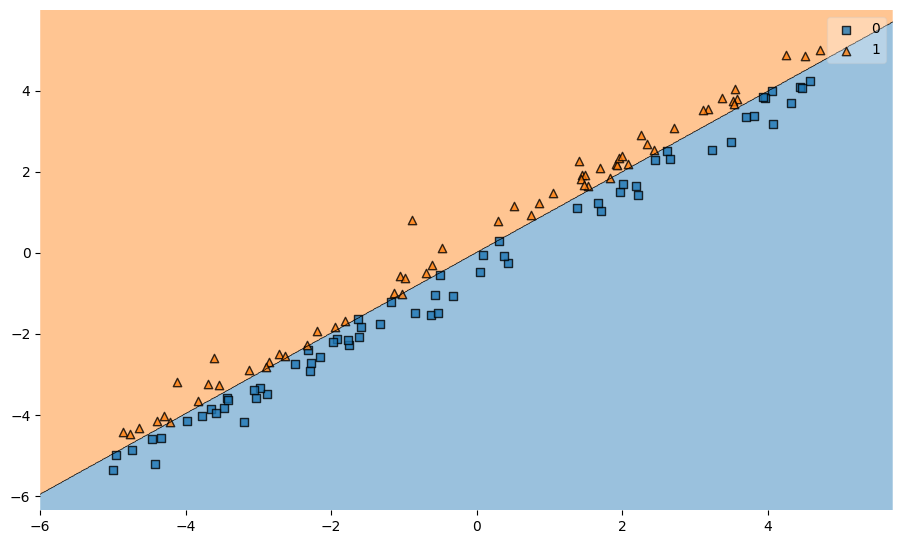

In [23]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_test, y_test, lr)

plt.show()

In [24]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_score(y_pred_dt, y_test)

0.872

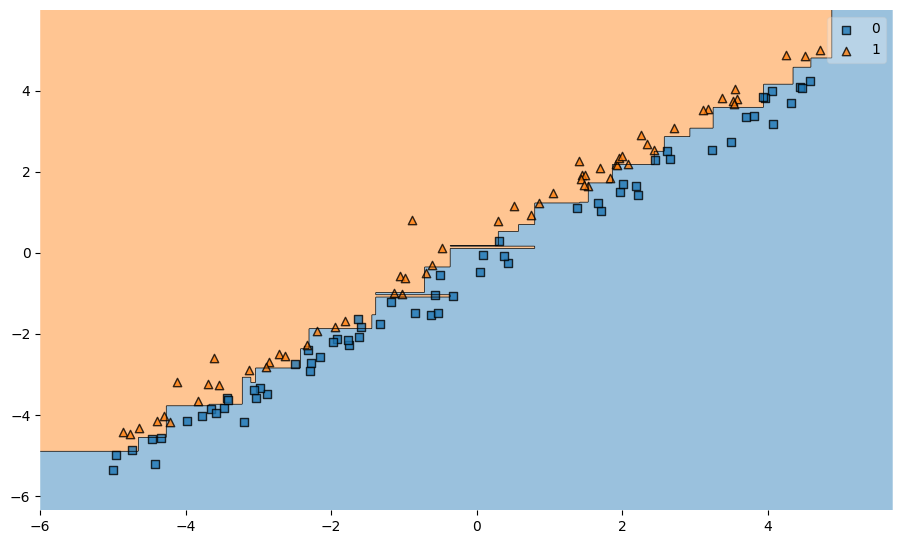

In [25]:
plot_decision_regions(X_test, y_test, dt)
plt.show()

____

## Let's consider other case where Decision tree's outperform the Logistic regression in terms of performance

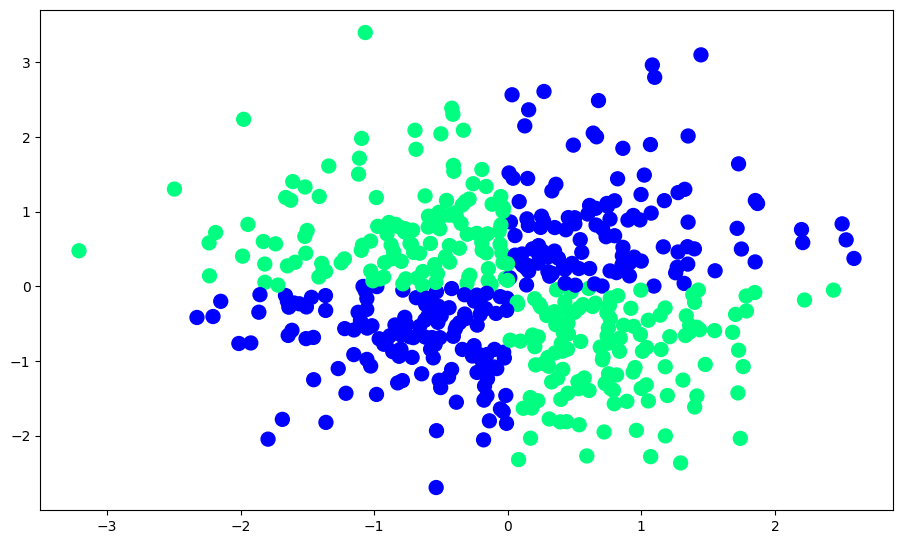

In [26]:
# Create synthetic data
np.random.seed(13)
X = np.random.randn(500, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)
plt.scatter(X[:, 0], X[:, 1], s=100, c=y, cmap="winter")
plt.show()

In [27]:
# Implementation of Logistic regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_score(y_pred_lr, y_test)

0.36

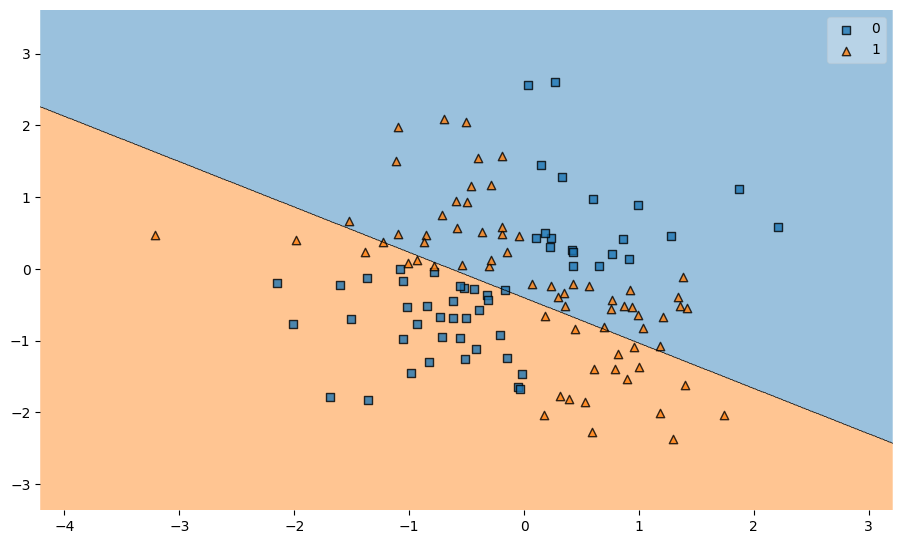

In [28]:
plot_decision_regions(X_test, y_test, lr)
plt.show()

In [29]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_score(y_pred_dt, y_test)

1.0

In [30]:
dt.get_depth()

6

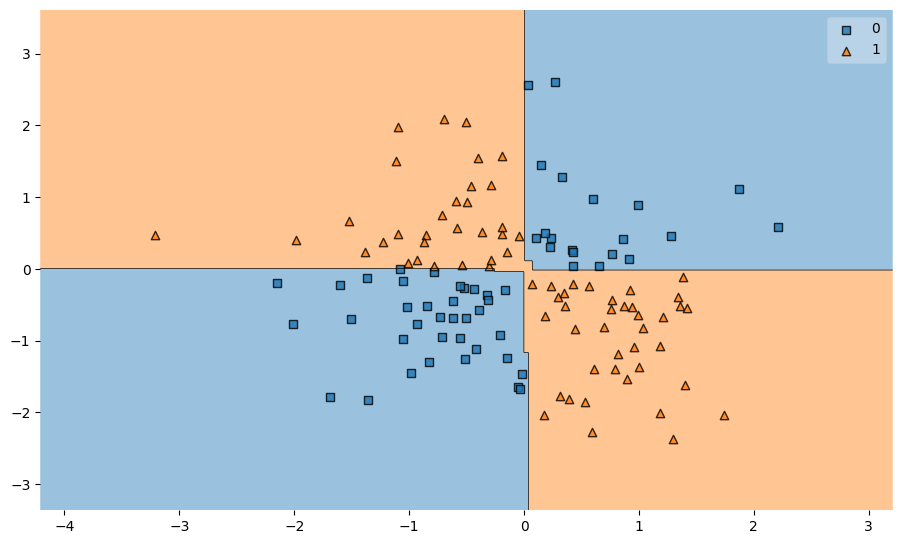

In [31]:
plot_decision_regions(X_test, y_test, dt)
plt.show()

**Task :**

| Column (X)        | English Description                | Russian Description              | Uzbek Description   |
| ----------------- | ---------------------------------- | -------------------------------- | ------------------- |
| sepal length (cm) | Length of the sepal in centimeters | Длина чашелистика в сантиметрах  | Sepal uzunligi (sm) |
| sepal width (cm)  | Width of the sepal in centimeters  | Ширина чашелистика в сантиметрах | Sepal kengligi (sm) |
| petal length (cm) | Length of the petal in centimeters | Длина лепестка в сантиметрах     | Petal uzunligi (sm) |
| petal width (cm)  | Width of the petal in centimeters  | Ширина лепестка в сантиметрах    | Petal kengligi (sm) |


| Value | English Species Name | Russian Species Name | Uzbek Species Name |
| ----- | -------------------- | -------------------- | ------------------ |
| 0     | Iris setosa          | Ирис сетоса          | Iris setosa        |
| 1     | Iris versicolor      | Ирис разноцветный    | Iris versicolor    |
| 2     | Iris virginica       | Ирис виргинский      | Iris virginica     |


In [32]:
from sklearn.datasets import load_iris

data = load_iris()
X_data = pd.DataFrame(data.data, columns = ["Sepal Length (cm)", "Sepal Width (cm)", "Petal Length (cm)", "Petal Width (cm)"])
y = data.target

In [33]:
X_data.drop(columns = ["Petal Length (cm)", "Petal Width (cm)"], inplace = True)
X_data

,Sepal Length (cm),Sepal Width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [34]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [35]:
# Dividing dataset into training and test parts
X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size = 0.2, random_state = 45)

In [ ]:
# Train model for training and test parts. Canculate accuracy metric for the models
dt = DecisionTreeClassifier(ccp_alpha = 0.02532859, random_state = 1, criterion='entropy')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)


print(f"Train accuracy : {accuracy_score(y_pred_dt, y_train)}")
print(f"Test accuracy : {accuracy_score(y_pred_dt_test, y_test)}")

Train accuracy : 0.775
Test accuracy : 0.7666666666666667


c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [37]:
dt.get_depth()

3

**Overtraining problem**

In [38]:
X_test

,Sepal Length (cm),Sepal Width (cm)
0,5.1,3.5
43,5.0,3.5
129,7.2,3.0
3,4.6,3.1
34,4.9,3.1
44,5.1,3.8
38,4.4,3.0
105,7.6,3.0
123,6.3,2.7
140,6.7,3.1


In [39]:
X_test = np.array(X_test)
X_test

array([[5.1, 3.5],
       [5. , 3.5],
       [7.2, 3. ],
       [4.6, 3.1],
       [4.9, 3.1],
       [5.1, 3.8],
       [4.4, 3. ],
       [7.6, 3. ],
       [6.3, 2.7],
       [6.7, 3.1],
       [5.2, 3.4],
       [7.2, 3.2],
       [5.7, 2.5],
       [6.3, 2.9],
       [6.3, 2.8],
       [5. , 3.2],
       [6.7, 3. ],
       [5.8, 2.7],
       [5. , 3.5],
       [6.3, 2.3],
       [5.4, 3. ],
       [6. , 3.4],
       [6.4, 3.2],
       [6.4, 3.2],
       [5. , 3.6],
       [6.8, 3. ],
       [5.8, 2.6],
       [5.6, 2.9],
       [5.4, 3.7],
       [6.1, 3. ]])

In [40]:
y_test

array([0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 1, 1, 1,
       2, 1, 0, 2, 1, 1, 0, 1])

c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


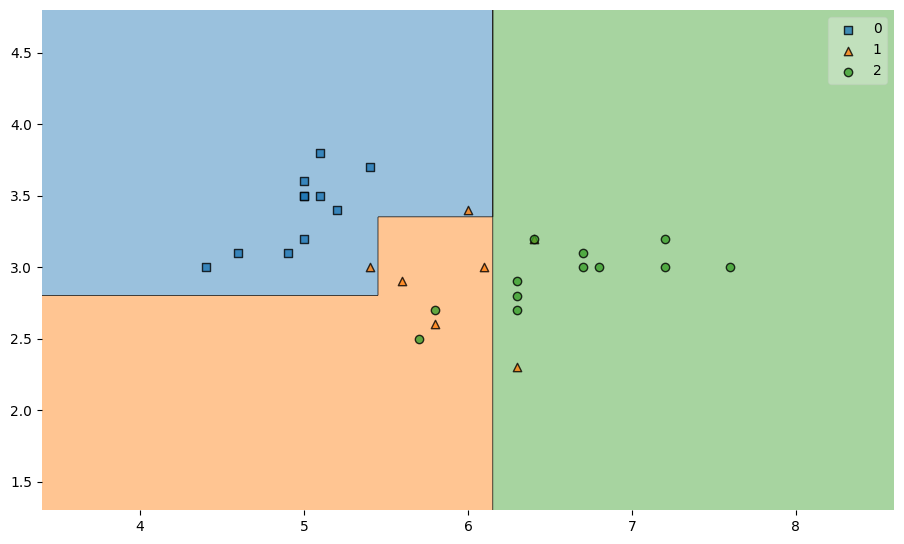

In [41]:
plot_decision_regions(X_test, y_test, dt)
plt.show()

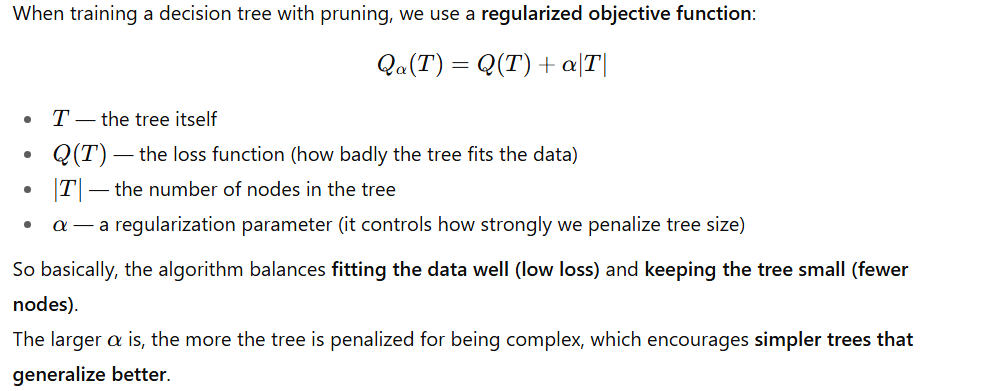

sklearn has Cost-Complexity Pruning, which returns a list of possible thresholds $\alpha$ when building a tree (since there is a finite number of data, there is no need to consider an infinite number of values).

    tree.cost_complexity_pruning_path(X_train, y_train)

In [50]:
cs_prune = dt.cost_complexity_pruning_path(X_train, y_train)['ccp_alphas']
cs_prune

array([0.        , 0.00356147, 0.00629073, 0.00954373, 0.01037594,
       0.01053665, 0.01293085, 0.01302766, 0.01666667, 0.02107771,
       0.02144553, 0.0229574 , 0.02532859, 0.0393689 , 0.04204485,
       0.05491167, 0.06362893, 0.12719292, 0.26607355, 0.50274113])

In [51]:
# Function to train Decision tree and calculating accuracy scores both in train and test
def model_dc(ccp) :
    dc = DecisionTreeClassifier(ccp_alpha = ccp, random_state = 42, criterion='entropy')
    dc.fit(X = X_train, y = y_train)

    pred_train = dc.predict(X = X_train)
    pred_test = dc.predict(X = X_test)

    accuracy_train = accuracy_score(y_true = y_train, y_pred = pred_train)
    accuracy_test = accuracy_score(y_true = y_test, y_pred = pred_test)

    return accuracy_train, accuracy_test

c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\

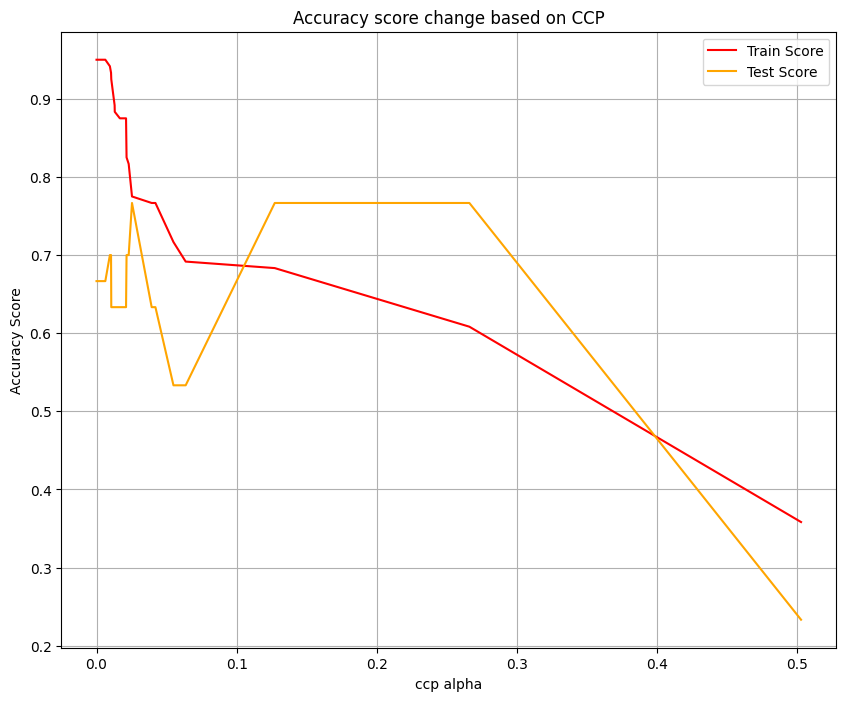

In [52]:
accuracy_score_train = [model_dc(i)[0] for i in cs_prune]
accuracy_score_test = [model_dc(i)[1] for i in cs_prune]

plt.figure(figsize = (10, 8))
plt.title(label = "Accuracy score change based on CCP")
plt.plot(cs_prune, accuracy_score_train, color = 'red', label = 'Train Score')
plt.plot(cs_prune, accuracy_score_test, color = 'orange', label = 'Test Score')
plt.xlabel(xlabel = 'ccp alpha')
plt.ylabel(ylabel = 'Accuracy Score')
plt.grid()
plt.legend()
plt.show()

In [61]:
[model_dc(i)[0] for i in cs_prune]

c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\

[0.95,
 0.95,
 0.95,
 0.9416666666666667,
 0.9333333333333333,
 0.925,
 0.8916666666666667,
 0.8833333333333333,
 0.875,
 0.875,
 0.825,
 0.8166666666666667,
 0.775,
 0.7666666666666667,
 0.7666666666666667,
 0.7166666666666667,
 0.6916666666666667,
 0.6833333333333333,
 0.6083333333333333,
 0.35833333333333334]

In [62]:
[model_dc(i)[1] for i in cs_prune]

c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\

[0.6666666666666666,
 0.6666666666666666,
 0.6666666666666666,
 0.7,
 0.7,
 0.6333333333333333,
 0.6333333333333333,
 0.6333333333333333,
 0.6333333333333333,
 0.6333333333333333,
 0.7,
 0.7,
 0.7666666666666667,
 0.6333333333333333,
 0.6333333333333333,
 0.5333333333333333,
 0.5333333333333333,
 0.7666666666666667,
 0.7666666666666667,
 0.23333333333333334]

In [64]:
dt = DecisionTreeClassifier(ccp_alpha = 0.02532859, random_state = 1, criterion='entropy')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)

print(f"Train accuracy : {accuracy_score(y_pred_dt, y_train)}")
print(f"Test accuracy : {accuracy_score(y_pred_dt_test, y_test)}")

Train accuracy : 0.775
Test accuracy : 0.7666666666666667


c:\Users\Ziyo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


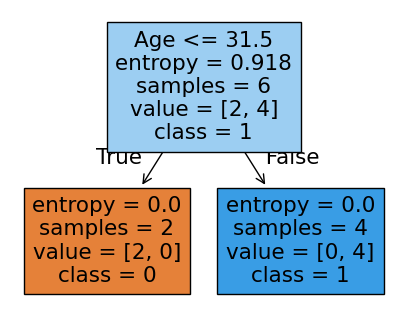

In [65]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree

# Модель с критерием энтропии
dc = DecisionTreeClassifier(criterion="entropy", random_state=0)
dc.fit(df.drop(columns="Buys"), df["Buys"])

# Визуализация
cols = df.drop(columns="Buys").columns
classes = df["Buys"].unique().astype(str)

plt.figure(figsize=(5, 4))
tree.plot_tree(dc, feature_names=cols, class_names=classes, filled=True)
plt.show()

___

## Accuracy score

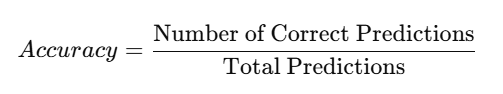

___

## Homework

| Column          | English Description                           | Russian Description                                          | Uzbek Description                            |
| --------------- | --------------------------------------------- | ------------------------------------------------------------ | -------------------------------------------- |
| **Age**         | Patient’s age in years                        | Возраст пациента в годах                                     | Bemor yoshi (yillarda)                       |
| **Sex**         | Patient’s gender (Male/Female)                | Пол пациента (Мужчина/Женщина)                               | Bemor jinsi (Erkak/Ayol)                     |
| **BP**          | Blood pressure level (Low, Normal, High)      | Уровень артериального давления (Низкое, Нормальное, Высокое) | Qon bosimi darajasi (Past, Normal, Yuqori)   |
| **Cholesterol** | Cholesterol level in the blood (Normal, High) | Уровень холестерина в крови (Нормальный, Высокий)            | Qondagi xolesterin darajasi (Normal, Yuqori) |
| **Na\_to\_K**   | Sodium to Potassium ratio in the blood        | Соотношение натрия к калию в крови                           | Qondagi natriy va kaliy nisbati              |
| **Drug**        | Type of drug prescribed to the patient        | Тип назначенного пациенту лекарства                          | Bemor uchun belgilangan dori turi            |


In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"
df = pd.read_csv(url)
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX
